## Test migration history reconstruction on Sanborn et. al. Melanoma data

In [1]:
import sys
import os

repo_dir = os.path.join(os.getcwd(), "metient/")

from metient import *
from metient.util import pairtree_data_extraction_util as ptutil

import matplotlib
import torch

matplotlib.rcParams['figure.figsize'] = [3, 3]
SANBORN_DATA_DIR = os.path.join(repo_dir, 'data', 'sanborn_melanoma_2015', 'cn_neutral_data')             

PATIENT_IDS = ['A', 'B', 'C', 'D', 'E', 'F', 'G']
print_config = PrintConfig(visualize=True)


In [3]:
MSK_MET_FREQ_FILE = '/data/morrisq/divyak/projects/metient/metient/data/msk_met/msk_met_freq_by_cancer_type.csv'

MAPPINGS = [
	# Patient A
	{
		'Parotid metastasis':'Head and Neck',
		'Locoregional skin metastasis 1, forehead':'Skin',
		'Locoregional skin metastasis 2, angle jaw':'Skin',
	},
	# Patient B
	{
		'Lymph node metastasis, left axilla':'Distant LN',
		'Locoregional skin metastasis 1, left back':'Skin',
		'Locoregional skin metastasis 2, left axilla':'Skin',
	},
	# Patient C
	{
		'Locoregional skin metastasis 1, right calf':'Skin',
		'Locoregional skin metastasis 2, right mid-calf':'Skin',
	},
	# Patient D
	{
		'Locoregional skin metastasis 1, right ankle':'Skin',
		'Locoregional skin metastasis 2, right leg':'Skin',
		'Lymph node metastasis, right groin':'Distant LN',
	},
	# Patient E
	{
		'Locoregional skin metastasis 1, left heel':'Skin',
		'Locoregional skin metastasis 2, left heel':'Skin',
		'Locoregional skin metastasis 3, left heel':'Skin',
		'Lymph node metastasis, left groin':'Distant LN',
	},
	# Patient F
	{
		'Locoregional skin metastasis, left ear':'Skin',
		'Distant skin metastasis, back':'Skin',
		'Lymph node metastasis, left cervical node':'Distant LN',
	},
	# Patient G
	{
		'Lung metastasis':'Lung',
		'Locoregional skin metastasis, axilla':'Skin',
	},
]
import pandas as pd

def get_metastasis_frequencies(site_mappings, met_freq_file):
    """
    Get normalized metastasis frequencies for each anatomical site from MSK data
    
    Args:
        site_mappings: List of dictionaries mapping sample sites to standardized categories
        met_freq_file: Path to CSV file containing metastasis frequencies
        
    Returns:
        List of dictionaries containing normalized frequencies for each patient's sites
    """
    # Read metastasis frequency data
    met_freq_df = pd.read_csv(met_freq_file)
    ovarian_freq = met_freq_df[met_freq_df['Cancer Type'] == 'Ovarian Cancer']


    # Get frequencies for our site categories
    O_by_patient = []
    for mapping in site_mappings:
        O = {}
        for mcpherson_site, msk_site in mapping.items():
            freq = float(ovarian_freq[msk_site].iloc[0])
            O[mcpherson_site] = freq
			
        # Normalize frequencies
        total = sum(O.values())
        print("\n",O)
        if total > 0:
            O = {k:v/total for k,v in O.items()}
        print(O)
        O_by_patient.append(O)
        
    return O_by_patient

Os = get_metastasis_frequencies(MAPPINGS, MSK_MET_FREQ_FILE)


 {'Parotid metastasis': 6.0, 'Locoregional skin metastasis 1, forehead': 112.0, 'Locoregional skin metastasis 2, angle jaw': 112.0}
{'Parotid metastasis': 0.02608695652173913, 'Locoregional skin metastasis 1, forehead': 0.48695652173913045, 'Locoregional skin metastasis 2, angle jaw': 0.48695652173913045}

 {'Lymph node metastasis, left axilla': 416.0, 'Locoregional skin metastasis 1, left back': 112.0, 'Locoregional skin metastasis 2, left axilla': 112.0}
{'Lymph node metastasis, left axilla': 0.65, 'Locoregional skin metastasis 1, left back': 0.175, 'Locoregional skin metastasis 2, left axilla': 0.175}

 {'Locoregional skin metastasis 1, right calf': 112.0, 'Locoregional skin metastasis 2, right mid-calf': 112.0}
{'Locoregional skin metastasis 1, right calf': 0.5, 'Locoregional skin metastasis 2, right mid-calf': 0.5}

 {'Locoregional skin metastasis 1, right ankle': 112.0, 'Locoregional skin metastasis 2, right leg': 112.0, 'Lymph node metastasis, right groin': 416.0}
{'Locoregiona

## Run Metient using orchard's eta estimation for U

Saving results to /lila/data/morrisq/divyak/projects/metient/metient/data/sanborn_melanoma_2015/metient_outputs_solve_polys_no_cna_pyclone_vi_orchard_eta/calibrate
Overwriting existing directory at /lila/data/morrisq/divyak/projects/metient/metient/data/sanborn_melanoma_2015/metient_outputs_solve_polys_no_cna_pyclone_vi_orchard_eta/calibrate

*** Calibrating for patient: A_calibrate ***
O: None
Tumor samples: ['Primary, forehead', 'Parotid metastasis', 'Locoregional skin metastasis 1, forehead', 'Locoregional skin metastasis 2, angle jaw']


  0%|          | 0/2800 [00:00<?, ?it/s]/lila/home/koyyald/mambaforge/envs/met/lib/python3.8/site-packages/torch/cuda/amp/grad_scaler.py:125: UserWarning: torch.cuda.amp.GradScaler is enabled, but CUDA is not available.  Disabling.
  warnings.warn(
/lila/home/koyyald/mambaforge/envs/met/lib/python3.8/site-packages/torch/optim/lr_scheduler.py:136: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn("Detected call of `lr_scheduler.step()` before `optimizer.step()`. "
100%|█████████▉| 2791/2800 [00:21<00:00, 143.71it/s]

Number of Pareto-optimal solutions: 1

*** Calibrating for patient: B_calibrate ***
O: None
Tumor samples: ['Primary, mid-left back', 'Lymph node metastasis, left axilla', 'Locoregional skin metastasis 1, left back', 'Locoregional skin metastasis 2, left axilla']


100%|██████████| 2800/2800 [00:22<00:00, 126.56it/s]
/lila/home/koyyald/mambaforge/envs/met/lib/python3.8/site-packages/torch/cuda/amp/grad_scaler.py:125: UserWarning: torch.cuda.amp.GradScaler is enabled, but CUDA is not available.  Disabling.
  warnings.warn(
/lila/home/koyyald/mambaforge/envs/met/lib/python3.8/site-packages/torch/optim/lr_scheduler.py:136: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn("Detected call of `lr_scheduler.step()` before `optimizer.step()`. "
100%|█████████▉| 2786/2800 [00:18<00:00, 152.18it/s]

Number of Pareto-optimal solutions: 1

*** Calibrating for patient: C_calibrate ***
O: None
Tumor samples: ['Primary, right lower calf', 'Locoregional skin metastasis 1, right calf', 'Locoregional skin metastasis 2, right mid-calf']


...

100%|██████████| 2800/2800 [00:23<00:00, 117.42it/s]
/lila/home/koyyald/mambaforge/envs/met/lib/python3.8/site-packages/torch/cuda/amp/grad_scaler.py:125: UserWarning: torch.cuda.amp.GradScaler is enabled, but CUDA is not available.  Disabling.
  warnings.warn(
/lila/home/koyyald/mambaforge/envs/met/lib/python3.8/site-packages/torch/optim/lr_scheduler.py:136: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn("Detected call of `lr_scheduler.step()` before `optimizer.step()`. "
100%|█████████▉| 2796/2800 [00:22<00:00, 127.40it/s]

Number of Pareto-optimal solutions: 1

*** Calibrating for patient: G_calibrate ***
O: None
Tumor samples: ['Primary, right forearm', 'Lung metastasis', 'Locoregional skin metastasis, axilla']


100%|██████████| 2800/2800 [00:26<00:00, 105.42it/s]
/lila/home/koyyald/mambaforge/envs/met/lib/python3.8/site-packages/torch/cuda/amp/grad_scaler.py:125: UserWarning: torch.cuda.amp.GradScaler is enabled, but CUDA is not available.  Disabling.
  warnings.warn(
/lila/home/koyyald/mambaforge/envs/met/lib/python3.8/site-packages/torch/optim/lr_scheduler.py:136: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn("Detected call of `lr_scheduler.step()` before `optimizer.step()`. "
100%|█████████▉| 2787/2800 [00:19<00:00, 146.71it/s]

Number of Pareto-optimal solutions: 1
Calibrating to 1 patients
Early stopping after 403 epochs.
Optimized thetas: tensor([0.37, 0.33, 0.30], grad_fn=<DivBackward0>)
A_calibrate_Primary, forehead


<Figure size 300x300 with 0 Axes>

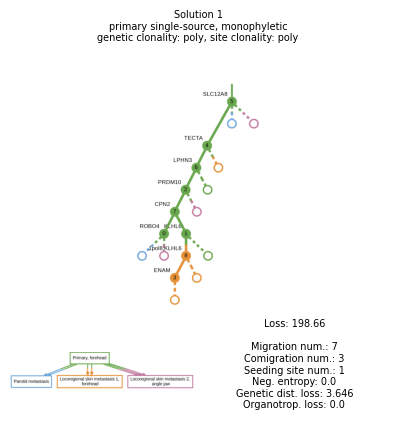

B_calibrate_Primary, mid-left back


<Figure size 300x300 with 0 Axes>

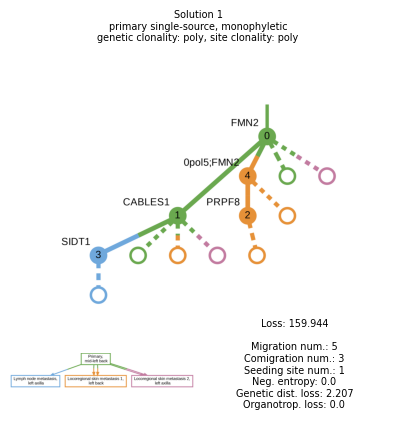

C_calibrate_Primary, right lower calf


<Figure size 300x300 with 0 Axes>

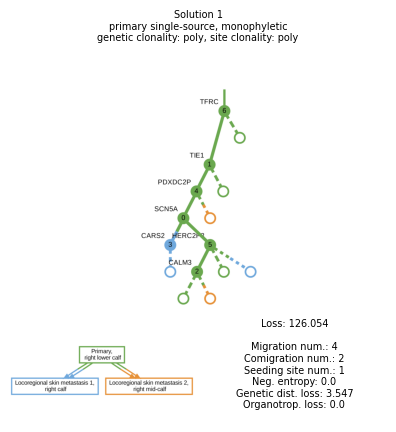

D_calibrate_Primary, right ankle


<Figure size 300x300 with 0 Axes>

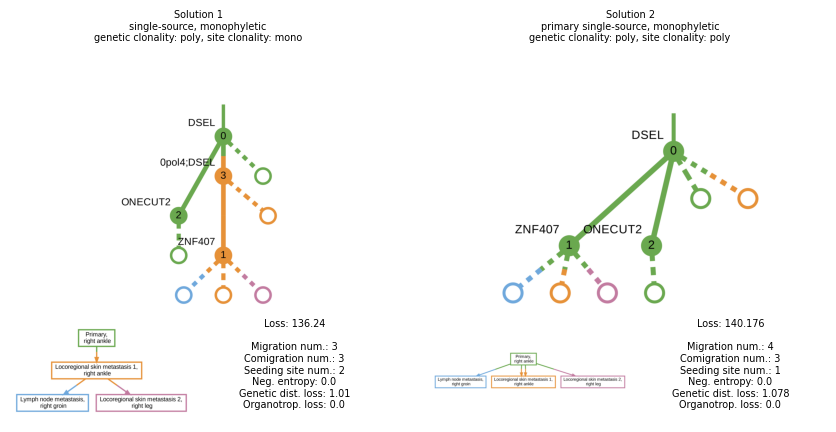

E_calibrate_Primary, left heel


<Figure size 300x300 with 0 Axes>

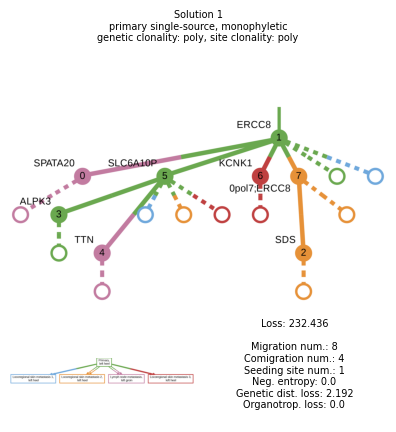

F_calibrate_Primary, left ear


<Figure size 300x300 with 0 Axes>

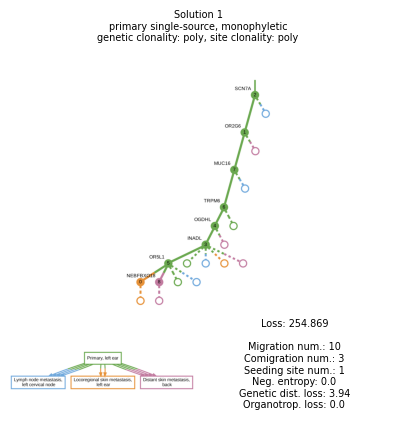

G_calibrate_Primary, right forearm


<Figure size 300x300 with 0 Axes>

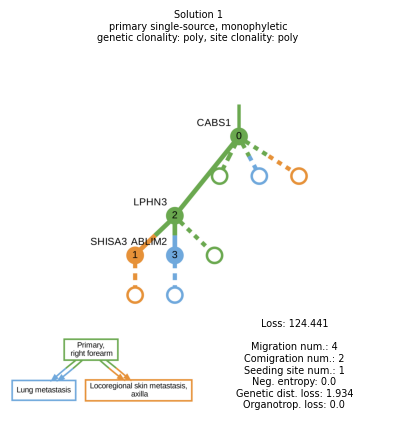

[0.37276676297187805, 0.33183518052101135, 0.29539811611175537]

100%|██████████| 2800/2800 [00:38<00:00, 146.71it/s]

In [4]:
# %%prun

OUTPUT_DIR = os.path.join(repo_dir, 'data', 'sanborn_melanoma_2015', "metient_outputs_solve_polys_no_cna_pyclone_vi_orchard_eta")
TREE_DIR = os.path.join(SANBORN_DATA_DIR, 'pyclone_vi_orchard_trees')    
TSV_DIR = os.path.join(SANBORN_DATA_DIR, 'pyclone_vi_orchard_eta_clustered_tsvs')  

mut_trees_fns = [os.path.join(TREE_DIR, f"{patient_id}.results.npz") for patient_id in PATIENT_IDS]
trees = [data[0] for data in ptutil.get_adj_matrices_from_pairtree_results(mut_trees_fns)]
ref_var_fns = [os.path.join(TSV_DIR, f"{patient_id}_SNVs.tsv") for patient_id in PATIENT_IDS]
run_names = [f"{pid}_calibrate" for pid in PATIENT_IDS]
calibrate_label_clone_tree(trees, ref_var_fns, print_config, OUTPUT_DIR, 
                           run_names, sample_size=1024, solve_polytomies=True)


## Run Metient using metient's U estimation

In [ ]:
#%%prun
TREE_DIR = os.path.join(SANBORN_DATA_DIR, 'pyclone_vi_orchard_trees')    
TSV_DIR = os.path.join(SANBORN_DATA_DIR, 'pyclone_vi_clustered_tsvs')    
OUTPUT_DIR = os.path.join(repo_dir, 'data', 'sanborn_melanoma_2015', "metient_outputs","metient_outputs_test")

mut_trees_fns = [os.path.join(TREE_DIR, f"{patient_id}.results.npz") for patient_id in PATIENT_IDS]
print(mut_trees_fns)
trees = [data[0] for data in ptutil.get_adj_matrices_from_pairtree_results(mut_trees_fns)]
ref_var_fns = [os.path.join(TSV_DIR, f"{patient_id}_SNVs.tsv") for patient_id in PATIENT_IDS]
print(ref_var_fns)
run_names = [f"{pid}_calibrate" for pid in PATIENT_IDS]
calibrate(trees, ref_var_fns, print_config, OUTPUT_DIR, run_names, sample_size=4096, solve_polytomies=True)
